In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests  # HTTP library for Python
import bs4
import math
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import gsw
%matplotlib inline
import os
import sys
import xmitgcm 
import xgcm
import pyproj
#import wget
#sys.path.append('../../ECCOv4-py/ECCOv4-py')
#import ecco_v4_py as ecco
import cmocean
sys.path.append('/home/basil/Desktop/cape_mend_SM_LCS/datatools')
from datatools import datatools as tools
#from moviepy.config import change_settings
#change_settings({"FFMPEG_BINARY": "/usr/bin/ffmpeg"})
#import moviepy.video.io.ImageSequenceClip 

from scipy.fft import fft, fftfreq
from scipy.signal import periodogram
from scipy.signal import welch
from scipy.stats import chi2
from opendrift.readers import reader_netCDF_CF_generic
from opendrift.readers import reader_global_landmask
import opendrift.readers as readers
from opendrift.models.oceandrift import OceanDrift
from datetime import timedelta
from scipy.interpolate import griddata

ModuleNotFoundError: No module named 'opendrift'

In [3]:
path_tohd = '/media/drdarby/Elements/data/Thesis/LLC4320/nc_files/'
grid_path = '/home/drdarby/Desktop/cape_mend_SM_LCS/data/cape_mend_grid_llc4320.nc'
grid = xr.open_dataset(grid_path)
variables = ['Eta','Theta','Salt','U','V','W','oceTUAX','oceTAUY']

In [3]:
hfr_files, hfr_filepaths = tools.get_data_paths_from_binary('/media/basil/Elements/data/Thesis/HFR/','nc_files',file_end='nc')
hfr = xr.open_mfdataset(hfr_filepaths)

In [4]:
hfr

<xarray.Dataset>
Dimensions:                (lat: 74, lon: 234, time: 8063, time_1: 1, nv: 2)
Coordinates:
  * lat                    (lat) float32 38.02 38.07 38.13 ... 41.85 41.9 41.95
  * lon                    (lon) float32 -130.4 -130.3 -130.2 ... -115.9 -115.8
  * time                   (time) datetime64[ns] 2012-01-01 ... 2012-12-01T23...
    time_run               (time) datetime64[ns] dask.array<chunksize=(744,), meta=np.ndarray>
Dimensions without coordinates: time_1, nv
Data variables: (12/14)
    time_bnds              (time, time_1, nv) int32 dask.array<chunksize=(744, 1, 2), meta=np.ndarray>
    depth_bnds             (time, nv) float32 dask.array<chunksize=(744, 2), meta=np.ndarray>
    wgs84                  (time) int8 -127 -127 -127 -127 ... -127 -127 -127
    processing_parameters  (time) int8 -127 -127 -127 -127 ... -127 -127 -127
    radial_metadata        (time) int8 -127 -127 -127 -127 ... -127 -127 -127
    depth                  (time) float32 1.4 1.4 1.4 1.4 ... 1.4 1.4 1.4 1.4
    ...                     ...
    v                      (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    dopx                   (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    dopy                   (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    hdop                   (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    number_of_sites        (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
    number_of_radials      (time, lat, lon) float32 dask.array<chunksize=(744, 74, 234), meta=np.ndarray>
Attributes: (12/31)
    Conventions:               CF-1.4, ACDD-1.3
    id:                        202311121400siohfruwlsrtvuswc6km
    date_created:              2023-11-12T16:23:28Z
    source:                    surface ocean velocity field from hf-radar
    program:                   Integrated Ocean Observing System (IOOS)
    title:                     Near-Real Time Surface Ocean Velocity, U.S. We...
    ...                        ...
    format_version:            1.1.00
    product_version:           2.0.00
    _CoordSysBuilder:          ucar.nc2.dataset.conv.CF1Convention
    cdm_data_type:             GRID
    featureType:               GRID
    location:                  Proto fmrc:HFRADAR_US_West_Coast_6km_Resolutio...

In [ ]:
U_files, U_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[3],file_end='nc')
U = xr.open_mfdataset(U_filepaths)

In [ ]:
# U = xr.merge([U,grid])

In [ ]:
V_files, V_filepaths = tools.get_data_paths_from_binary(path_tohd,variables[4],file_end='nc')
V = xr.open_mfdataset(V_filepaths)

In [ ]:
# V = xr.merge([V,grid])

In [ ]:
# U = U.set_coords({'XC','YC'})
# V = V.set_coords({'XC','YC'})
# extent = [-127.59791666666666,-123.10208333333333,38.50208333333333,41.99791666666667]
# ds = U
# ds_cut = ds.where(((ds['XC']>extent[0])&(ds['XC']<extent[1]))&(ds['YC']>extent[2])&(ds['YC']<extent[3]))
# ds_cut_U = ds_cut.dropna(how='all',dim='i').dropna(how='all',dim='j') #this code takes forever


In [ ]:
# ds = V
# ds_cut = ds.where(((ds['XC']>extent[0])&(ds['XC']<extent[1]))&(ds['YC']>extent[2])&(ds['YC']<extent[3]))
# ds_cut_V = ds_cut.dropna(how='all',dim='i').dropna(how='all',dim='j') #this code takes forever

In [ ]:
# uv = xr.merge([ds_cut_U,ds_cut_V])

In [5]:
#uv.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/uv_cut_gridded.nc')
uv_model = xr.open_dataset('/media/drdarby/Elements/data/Thesis/LLC4320/uv_cut_gridded.nc')

uv_model=uv_model.set_coords({'XC','YC'}).rename({'XC':'lon','YC':'lat','U':'u','V':'v'})

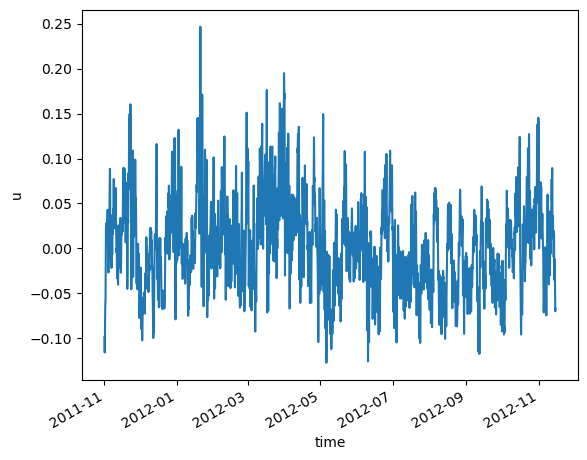

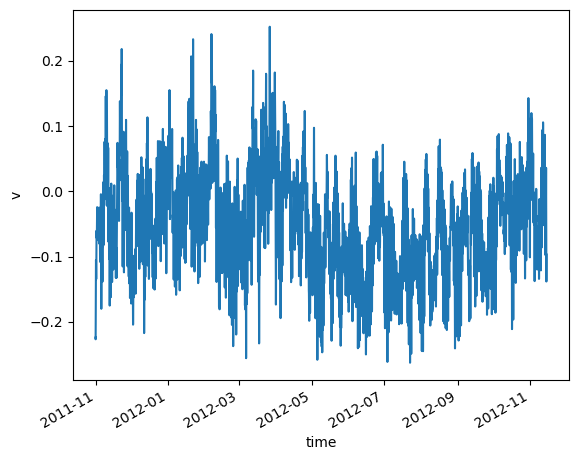

In [8]:

uv_model['u'].isel.mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(label='u')
plt.show()
uv_model['v'].mean(dim='i',skipna=True).mean(dim='j',skipna=True).plot(label='v')

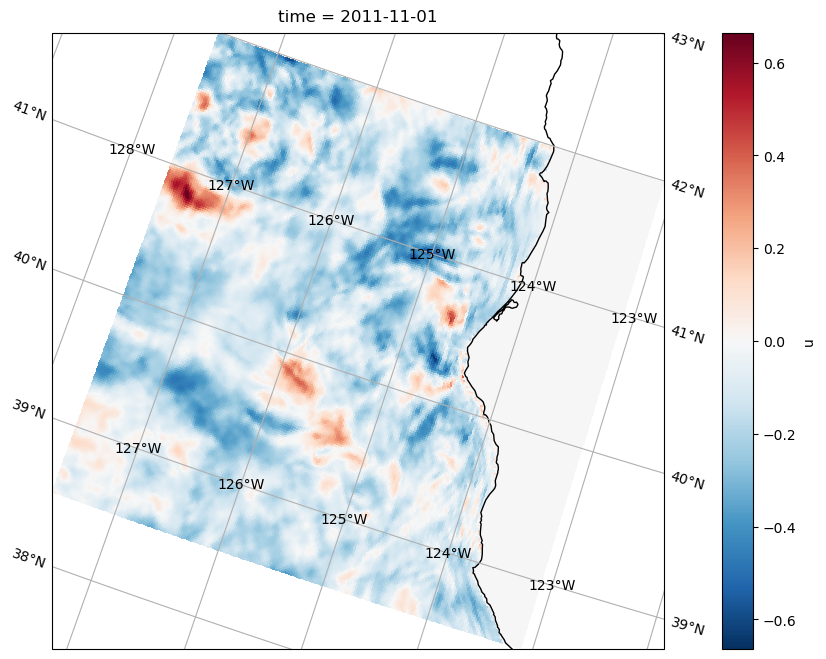

In [6]:
proj = ccrs.LambertConformal()
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=proj)
uv_model['u'].isel(time=0).plot(x='lon',y='lat',transform=ccrs.PlateCarree())

# coast_10m = cfeature.NaturalEarthFeature("physical", "land", "10m", edgecolor="k", facecolor="0.8")
# #plt.title("6 hour attracting LCS at " + str(np.array(LCS.time)[0])[0:13]) 
# ax.add_feature(coast_10m)

gl = ax.gridlines(draw_labels=True)
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
ax.coastlines()

plt.savefig('./vel_proj')

In [ ]:
# o = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
# o_diffusion = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
# o.set_config('general:coastline_action', 'stranding') 
# o.set_config('drift:advection_scheme', 'runge-kutta4')
# o.set_config('general:time_step_minutes', 60)
# o.set_config('drift:stokes_drift', False)

# o_diffusion.set_config('general:coastline_action', 'stranding') 
# o_diffusion.set_config('drift:advection_scheme', 'runge-kutta4')
# o_diffusion.set_config('general:time_step_minutes', 60)
# o_diffusion.set_config('drift:stokes_drift', False)
# o_diffusion.set_config('drift:current_uncertainty_uniform', .5) # uncertainty .2 meters per sec. this is a uniform distribution from -.2 to .2
# o_diffusion.set_config('drift:current_uncertainty', .2) # uncertainty 

In [ ]:
# uv['u'].attrs['long_name'] = 'surface_eastward_sea_water_velocity'
# uv['u'].attrs['units'] = 'm s-1'
# uv['u'].attrs['standard_name'] = 'surface_eastward_sea_water_velocity'
# uv['v'].attrs['long_name'] = 'surface_northward_sea_water_velocity'
# uv['v'].attrs['units'] = 'm s-1'
# uv['v'].attrs['standard_name'] = 'surface_northward_sea_water_velocity'
# uv['lat'].attrs['long_name'] = 'latitude'
# uv['lat'].attrs['units'] = 'degrees_north'
# uv['lat'].attrs['standard_name'] = 'latitude'
# uv['lat'].attrs['_CoordinateAxisType']='Lat'
# uv['lon'].attrs['long_name'] = 'longitude'
# uv['lon'].attrs['units'] = 'degrees_east'
# uv['lon'].attrs['standard_name'] = 'longitude'
# uv['lon'].attrs['_CoordinateAxisType']='Lon'
# uv.set_coords({'lat','lon'})
# units :
#     degrees_north
# long_name :
#     latitude
# standard_name :
#     latitude
# _ChunkSizes :
#     367
# _CoordinateAxisType :
#     Lat

# lon
# (lon)
# float32
# -130.4 -130.3 ... -115.9 -115.8

# units :
#     degrees_east
# long_name :
#     longitude
# standard_name :
#     longitude
# _ChunkSizes :
#     234
# _CoordinateAxisType :
#     Lon

In [7]:
from pprint import pprint

In [11]:

extent = [-127.59791666666666,-123.10208333333333,38.50208333333333,41.99791666666667]
#need to rename things

In [ ]:
# uv_filepaths = ['/media/basil/Elements/data/Thesis/LLC4320/u_latlon.nc','/media/basil/Elements/data/Thesis/LLC4320/v_latlon.nc']

In [ ]:
# uv = xr.open_mfdataset(uv_filepaths)

In [ ]:
# uv['u'].attrs['long_name'] = 'surface_eastward_sea_water_velocity'
# uv['u'].attrs['units'] = 'm s-1'
# uv['u'].attrs['standard_name'] = 'surface_eastward_sea_water_velocity'
# uv['v'].attrs['long_name'] = 'surface_northward_sea_water_velocity'
# uv['v'].attrs['units'] = 'm s-1'
# uv['v'].attrs['standard_name'] = 'surface_northward_sea_water_velocity'
# uv['lat'].attrs['long_name'] = 'latitude'
# uv['lat'].attrs['units'] = 'degrees_north'
# uv['lat'].attrs['standard_name'] = 'latitude'
# uv['lat'].attrs['_CoordinateAxisType']='Lat'
# uv['lon'].attrs['long_name'] = 'longitude'
# uv['lon'].attrs['units'] = 'degrees_east'
# uv['lon'].attrs['standard_name'] = 'longitude'
# uv['lon'].attrs['_CoordinateAxisType']='Lon'


In [ ]:
# uv_cut = uv.isel(time=slice(0,24*5))

In [ ]:
# uv_cut['u'].isel(time=0).plot()

In [ ]:
uv_model

In [9]:
#convert to spatial coordinates
import pyproj
lat_box = np.array(uv_model['lat'][:,:])
print(np.shape(lat_box))

lon_box = np.array(uv_model['lon'][:,:])
print(np.shape(lon_box))
source_crs = 'epsg:3310'#3310 # Coordinate system of the file
target_crs = 'epsg:4326' 
latlon_to_polar = pyproj.Transformer.from_crs(target_crs, source_crs)
proj_in_x, proj_in_y = latlon_to_polar.transform(lat_box, lon_box)


(237, 216)
(237, 216)


In [10]:
#print(np.array(uv_model['lon'][0,:]))
X = np.array(proj_in_x[0,:])
Y = np.array(proj_in_y[:,0])

In [ ]:
# time_cut = uv_cut['time']

# spatial_u = xr.DataArray(np.array(uv_cut['u']),coords = [time_cut,Y,X], dims = ['time','Y','X'],name='u')
# spatial_v = xr.DataArray(np.array(uv_cut['v']),coords = [time_cut,Y,X], dims = ['time','Y','X'],name='v')


In [ ]:
# spatial_u.isel(time=0).plot()
# plt.show()
# uv_cut['u'].isel(time=0).plot()

In [ ]:
# spatial_u.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/test-working/u_spatial_short_try.nc')
# spatial_v.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/test-working/v_spatial_short_try.nc')

In [ ]:
# test_uv_filepaths = ['/media/basil/Elements/data/Thesis/LLC4320/test-working/v_spatial_short_try.nc','/media/basil/Elements/data/Thesis/LLC4320/test-working/u_spatial_short_try.nc'] 
# test_uv_ = xr.open_mfdataset(test_uv_filepaths)
# test_uv['u'].attrs['long_name'] = 'surface_eastward_sea_water_velocity'
# test_uv['u'].attrs['units'] = 'm s-1'
# test_uv['u'].attrs['standard_name'] = 'surface_eastward_sea_water_velocity'
# test_uv['u'].attrs['grid_mapping'] = 'epsg:3310'
# test_uv['v'].attrs['long_name'] = 'surface_northward_sea_water_velocity'
# test_uv['v'].attrs['units'] = 'm s-1'
# test_uv['v'].attrs['standard_name'] = 'surface_northward_sea_water_velocity'
# test_uv['v'].attrs['grid_mapping'] = 'epsg:3310'
# test_uv['Y'].attrs['long_name'] = 'projection_y_coordinate'
# test_uv['Y'].attrs['units'] = 'm'
# test_uv['Y'].attrs['standard_name'] = 'projection_y_coordinate'

# test_uv['X'].attrs['long_name'] = 'projection_x_coordinate'
# test_uv['X'].attrs['units'] = 'm'
# test_uv['X'].attrs['standard_name'] = 'projection_x_coordinate'


In [ ]:
#test_uv



In [ ]:
#converts uv fields to a uniform grid and resamples to that grid
X_not_unif, Y_not_unif = np.meshgrid(X,Y)
X_uniform = np.arange(-660722,-271237,1804)
Y_uniform = np.arange(81172,465913,1624)
X_uniform_grid, Y_uniform_grid = np.meshgrid(X_uniform,Y_uniform)
points_model = np.column_stack([np.ravel(X_not_unif), np.ravel(Y_not_unif)])
for i in range(0,):
    U_uniform = griddata(points_model, np.array(model_uv['u'].isel(time=i)).ravel(), (X_uniform_grid.ravel(), Y_uniform_grid.ravel()))
    V_uniform = griddata(points_model, np.array(model_uv['v'].isel(time=i)).ravel(), (X_uniform_grid.ravel(), Y_uniform_grid.ravel()))
    v_corrected = np.reshape(V_uniform,(1,237,216))
    u_corrected = np.reshape(U_uniform,(1,237,216))
    time_cut = [np.array(test_uv.time)[i]]
    spatial_u = xr.DataArray(u_corrected,coords = [time_cut,Y_uniform,X_uniform], dims = ['time','Y','X'],name='u')
    spatial_v = xr.DataArray(v_corrected,coords = [time_cut,Y_uniform,X_uniform], dims = ['time','Y','X'],name='v')
    spatial_u.attrs['long_name'] = 'x_sea_water_velocity'
    spatial_u.attrs['units'] = 'm s-1'
    spatial_u.attrs['standard_name'] = 'x_sea_water_velocity'
    spatial_u.attrs['grid_mapping'] = 'epsg:3310'
    spatial_v.attrs['long_name'] = 'y_sea_water_velocity'
    spatial_v.attrs['units'] = 'm s-1'
    spatial_v.attrs['standard_name'] = 'y_sea_water_velocity'
    spatial_v.attrs['grid_mapping'] = 'epsg:3310'
    spatial_v['Y'].attrs['long_name'] = 'projection_y_coordinate'
    spatial_v['Y'].attrs['units'] = 'm'
    spatial_v['Y'].attrs['standard_name'] = 'projection_y_coordinate'
    spatial_u['Y'].attrs['long_name'] = 'projection_y_coordinate'
    spatial_u['Y'].attrs['units'] = 'm'
    spatial_u['Y'].attrs['standard_name'] = 'projection_y_coordinate'
    spatial_v['X'].attrs['long_name'] = 'projection_x_coordinate'
    spatial_v['X'].attrs['units'] = 'm'
    spatial_v['X'].attrs['standard_name'] = 'projection_x_coordinate'
    spatial_u['X'].attrs['long_name'] = 'projection_x_coordinate'
    spatial_u['X'].attrs['units'] = 'm'
    spatial_u['X'].attrs['standard_name'] = 'projection_x_coordinate'
    proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs'
    
    spatial_u.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/uv_regridded/u_spatial_short_proj_'+str(i).zfill(4)+'.nc')
    spatial_v.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/uv_regridded/v_spatial_short_proj_'+str(i).zfill(4)+'.nc')
#plt.plot(X_not_unif[1:25,1:25],Y_not_unif[1:25,1:25],'r.');
#plt.plot(X_uniform_grid[1:25,1:25],Y_uniform_grid[1:25,1:25],'b.');
#plt.plot(np.array(test_uv['X'])[1:25,1:25],np.array(test_uv['Y'])[1:25,1:25])
#ESMF

In [ ]:
# v_corrected = np.reshape(V_uniform,(1,237,216))
# u_corrected = np.reshape(U_uniform,(1,237,216))
# time_cut = [np.array(test_uv.time)[i]]
# spatial_u = xr.DataArray(u_corrected,coords = [time_cut,Y_uniform,X_uniform], dims = ['time','Y','X'],name='u')
# spatial_v = xr.DataArray(v_corrected,coords = [time_cut,Y_uniform,X_uniform], dims = ['time','Y','X'],name='v')
# spatial_u.attrs['long_name'] = 'x_sea_water_velocity'
# spatial_u.attrs['units'] = 'm s-1'
# spatial_u.attrs['standard_name'] = 'x_sea_water_velocity'
# spatial_u.attrs['grid_mapping'] = 'epsg:3310'
# spatial_v.attrs['long_name'] = 'y_sea_water_velocity'
# spatial_v.attrs['units'] = 'm s-1'
# spatial_v.attrs['standard_name'] = 'y_sea_water_velocity'
# spatial_v.attrs['grid_mapping'] = 'epsg:3310'
# spatial_v['Y'].attrs['long_name'] = 'projection_y_coordinate'
# spatial_v['Y'].attrs['units'] = 'm'
# spatial_v['Y'].attrs['standard_name'] = 'projection_y_coordinate'
# spatial_u['Y'].attrs['long_name'] = 'projection_y_coordinate'
# spatial_u['Y'].attrs['units'] = 'm'
# spatial_u['Y'].attrs['standard_name'] = 'projection_y_coordinate'
# spatial_v['X'].attrs['long_name'] = 'projection_x_coordinate'
# spatial_v['X'].attrs['units'] = 'm'
# spatial_v['X'].attrs['standard_name'] = 'projection_x_coordinate'
# spatial_u['X'].attrs['long_name'] = 'projection_x_coordinate'
# spatial_u['X'].attrs['units'] = 'm'
# spatial_u['X'].attrs['standard_name'] = 'projection_x_coordinate'
# proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs'

In [ ]:
# i=0
# spatial_u.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/uv_regridded/u_spatial_short_proj'+str(i).zfill(4)+'.nc')
# spatial_v.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/uv_regridded/v_spatial_short_proj'+str(i).zfill(4)+'.nc')

In [12]:
test_proj_files, test_proj_filepaths =  tools.get_data_paths_from_binary('/media/basil/Elements/data/Thesis/LLC4320/','test-working/uv_regridded',file_end='nc')
test_proj_uni = xr.open_mfdataset(test_proj_filepaths)

In [13]:
naned_test = test_proj_uni.where(np.logical_or(test_proj_uni['u'].mean(dim='time')>0 ,test_proj_uni['u'].mean(dim='time')<0))

In [16]:
#comparing projections
X_uniform = np.arange(-660722,-271237,1804)
Y_uniform = np.arange(81172,465913,1624)
X_uniform_grid, Y_uniform_grid = np.meshgrid(X_uniform,Y_uniform)
source_crs = 'epsg:3310'#3310 # Coordinate system of the file
target_crs = 'epsg:4326' 
latlon_to_polar = pyproj.Transformer.from_crs(source_crs,target_crs)
proj_in_lat, proj_in_lon = latlon_to_polar.transform(X_uniform_grid, Y_uniform_grid)



delta_x=1804
delta_y=1624
#xs = np.arange(reader_data.xmin, reader_data.xmax, delta_x)
#ys = np.arange(reader_data.ymin, reader_data.ymax, delta_y)

#proj = reader_data.proj
#X, Y = np.meshgrid(xs, ys)
#lons, lats = proj(X, Y, inverse=True)
#proj_in_lat, proj_in_lon
#xs == X_uniform[:-1]
#ys == Y_uniform[:-1]
#proj_in_lat
#proj_in_lon

#max((lcs['lon'] - proj_in_lon[:-1,:-1]).ravel())
#max((lcs['lat'] - proj_in_lat[:-1,:-1]).ravel())
#lons - proj_in_lon[:-1,:-1]


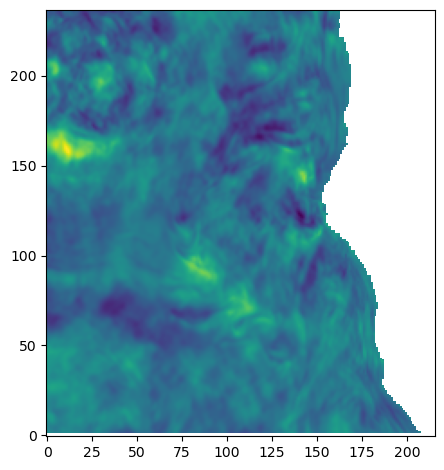

In [17]:
plt.imshow(np.array(naned_test['u'].isel(time=0)))
plt.gca().invert_yaxis()
plt.savefig('./naned_data.png')

In [18]:
naned_test_no = naned_test.dropna(how='all',dim='time')#.dropna(how='all',dim='Y')

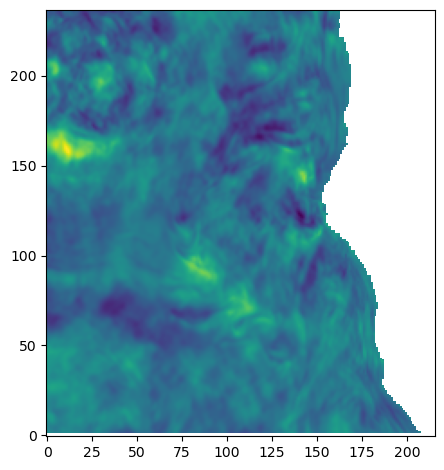

In [19]:
plt.imshow(np.array(naned_test_no['u'].isel(time=0)))#.plot()
plt.gca().invert_yaxis()


In [193]:
#Switching it back for the land mask
X_uniform = np.arange(-660722,-271237,1804)
Y_uniform = np.arange(81172,465913,1624)
X_uniform_grid, Y_uniform_grid = np.meshgrid(X_uniform,Y_uniform)
source_crs = 'epsg:3310'#3310 # Coordinate system of the file
target_crs = 'epsg:4326' 
latlon_to_polar = pyproj.Transformer.from_crs(source_crs,target_crs)
proj_in_lat, proj_in_lon = latlon_to_polar.transform(X_uniform_grid, Y_uniform_grid)

Land_mask = xr.DataArray(~np.isfinite(np.array(naned_test_no['u'].isel(time=0))),coords=[Y_uniform,X_uniform],dims=['Y','X'],name='land_binary_mask')
projection = xr.Dataset(data_vars = dict(projection=1),attrs=dict(earth_radius=6371000.0,proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs')) 
Land_mask

#test_uv_proj = xr.merge(test_uv,projection['projection'])
projection['projection'].attrs = projection.attrs
Land_mask
Land_mask=Land_mask.where(Land_mask,0)


test_uv_proj = xr.merge([naned_test_no,projection])
#test_uv_proj = xr.merge([test_uv_proj,Land_mask])

In [194]:
Land_mask=Land_mask.where(Land_mask,0).rename('land_binary_mask')
#np.ma.masked_array(np.array(naned_test_no['u'].isel(time=0)),mask = Land_mask)
Land_mask

<xarray.DataArray 'land_binary_mask' (Y: 237, X: 216)>
array([[1, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]])
Coordinates:
  * Y        (Y) int64 81172 82796 84420 86044 ... 459564 461188 462812 464436
  * X        (X) int64 -660722 -658918 -657114 ... -276470 -274666 -272862

In [195]:
Land_mask.attrs['grid_mapping']='epsg:3310'
Land_mask.attrs['long_name']='land_binary_mask'
Land_mask.attrs['standard_name']='land_binary_mask'
Land_mask['Y'].attrs['long_name'] = 'projection_y_coordinate'
Land_mask['Y'].attrs['units'] = 'm'
Land_mask['Y'].attrs['standard_name'] = 'projection_y_coordinate'
Land_mask['X'].attrs['long_name'] = 'projection_x_coordinate'
Land_mask['X'].attrs['units'] = 'm'
Land_mask['X'].attrs['standard_name'] = 'projection_x_coordinate'
Land_mask

<xarray.DataArray 'land_binary_mask' (Y: 237, X: 216)>
array([[1, 1, 1, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]])
Coordinates:
  * Y        (Y) int64 81172 82796 84420 86044 ... 459564 461188 462812 464436
  * X        (X) int64 -660722 -658918 -657114 ... -276470 -274666 -272862
Attributes:
    grid_mapping:   epsg:3310
    long_name:      land_binary_mask
    standard_name:  land_binary_mask

In [196]:
test_uv_proj= xr.merge([Land_mask,test_uv_proj])

KeyError: 'sea_floor_depth_below_sea_level'

In [113]:
test_uv_proj

<xarray.Dataset>
Dimensions:                          (Y: 237, X: 216, time: 6)
Coordinates:
  * Y                                (Y) int64 81172 82796 ... 462812 464436
  * X                                (X) int64 -660722 -658918 ... -272862
  * time                             (time) datetime64[ns] 2011-11-01 ... 201...
Data variables:
    sea_floor_depth_below_sea_level  (Y, X) int64 1 1 1 1 1 1 1 ... 1 1 1 1 1 1
    projection                       int64 1
    u                                (time, Y, X) float64 dask.array<chunksize=(1, 237, 216), meta=np.ndarray>
    v                                (time, Y, X) float64 dask.array<chunksize=(1, 237, 216), meta=np.ndarray>

In [75]:
import cartopy.io.shapereader as shpreader
from opendrift.readers import reader_shape
#Land_mask
shpfilename = shpreader.natural_earth(resolution='10m',
                                    category='cultural',
                                    name='admin_0_countries')
reader_natural = reader_shape.Reader.from_shpfiles(shpfilename)


In [93]:
from opendrift.readers import reader_shape

reader_shape.Reader(Land_mask)

TypeError: One of the arguments is of incorrect type. Please provide only Geometry objects.

In [64]:
test_uv_proj

<xarray.Dataset>
Dimensions:     (time: 6, Y: 237, X: 216)
Coordinates:
  * time        (time) datetime64[ns] 2011-11-01 ... 2011-11-01T05:00:00
  * Y           (Y) int64 81172 82796 84420 86044 ... 461188 462812 464436
  * X           (X) int64 -660722 -658918 -657114 ... -276470 -274666 -272862
Data variables:
    u           (time, Y, X) float64 dask.array<chunksize=(1, 237, 216), meta=np.ndarray>
    v           (time, Y, X) float64 dask.array<chunksize=(1, 237, 216), meta=np.ndarray>
    projection  int64 1

In [223]:
o = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o_diffusion = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o.set_config('general:coastline_action', 'previous') 
o.set_config('drift:advection_scheme', 'runge-kutta4')
o.set_config('general:time_step_minutes', 60)
o.set_config('drift:stokes_drift', False)
#o.set_config('seed:ocean_only', True)
o.set_config('general:use_auto_landmask', False)
#o.set_config('environment:fallback:land_binary_mask', 1)
o_diffusion.set_config('general:coastline_action', 'stranding') 
o_diffusion.set_config('drift:advection_scheme', 'runge-kutta4')
o_diffusion.set_config('general:time_step_minutes', 60)
o_diffusion.set_config('drift:stokes_drift', False)
o_diffusion.set_config('drift:current_uncertainty_uniform', 0)
o_diffusion.set_config('general:use_auto_landmask', False)
reader_data = reader_netCDF_CF_generic.Reader(test_uv_proj)
#reader_landmask = reader_netCDF_CF_generic.Reader(Land_mask)
#reader_landmask.activate_environment_mapping('land_binary_mask_from_ocean_depth')
#reader_data.activate_environment_mapping('land_binary_mask_from_ocean_depth')
o.add_reader([reader_data])
o_diffusion.add_reader([reader_data])

13:48:29 DEBUG   opendrift.models.oceandrift:116: No machine learning correction available.
13:48:29 DEBUG   opendrift.config:161: Adding 48 config items from environment
13:48:29 DEBUG   opendrift.config:161: Adding 5 config items from environment


In [224]:
#reader_landmask.activate_environment_mapping('land_binary_mask_from_ocean_depth')
o

Model:	OceanDrift     (OpenDrift version 1.11.0)
	0 active Lagrangian3DArray particles  (0 deactivated, 0 scheduled)
-------------------
Environment variables:
  -----
  land_binary_mask
  x_sea_water_velocity
  y_sea_water_velocity
     1) <xarray.Dataset>
Dimensions:           (Y: 237, X: 216, time: 6)
Coordinates:
  * Y                 (Y) int64 81172 82796 84420 86044 ... 461188 462812 464436
  * X                 (X) int64 -660722 -658918 -657114 ... -274666 -272862
  * time              (time) datetime64[ns] 2011-11-01 ... 2011-11-01T05:00:00
Data variables:
    land_binary_mask  (Y, X) int64 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
    u                 (time, Y, X) float64 dask.array<chunksize=(1, 237, 216), meta=np.ndarray>
    v                 (time, Y, X) float64 dask.array<chunksize=(1, 237, 216), meta=np.ndarray>
    projection        int64 1
Attributes:
    grid_mapping:   epsg:3310
    long_name:      land_binary_mask
    standard_name:  land_binary_mask
  -----
Re

In [225]:
def ftle_fixed(X, Y, delta_x, delta_y, duration):
    """Calculate Finite Time Lyapunov Exponents"""
    # From Johannes Rohrs
    nx = X.shape[0]
    ny = X.shape[1]
    J = np.empty([nx,ny,2,2], np.float32)
    FTLE = np.empty([nx,ny], np.float32)

    # gradient
    dx = np.gradient(X)
    dy = np.gradient(Y)

    # Jacobian
    J[:,:,0,0] = dx[0] / (2*delta_x)
    J[:,:,1,0] = dy[0] / (2*delta_y)
    J[:,:,0,1] = dx[1] / (2*delta_x)
    J[:,:,1,1] = dy[1] / (2*delta_y)

    for i in range(0,nx):
        for j in range(0,ny):
            # Green-Cauchy tensor
            D = np.dot(np.transpose(J[i,j]), J[i,j])
            # its largest eigenvalue
            lamda = np.linalg.eigvals(D)
            FTLE[i,j] = np.log(np.sqrt(max(lamda)))/np.abs(duration)

    return FTLE





In [226]:
def calculate_ftle_fixed(self,
                       lats_input=None
                       lons_input=None
                       reader=None,
                       delta_x=None,
                       delta_y=None,
                       domain=None,
                       time=None,
                       time_step=None,
                       duration=None,
                       z=0,
                       RLCS=True,
                       ALCS=True):

        if reader is None:
            logger.info('No reader provided, using first available:')
            reader = list(self.env.readers.items())[0][1]
            logger.info(reader.name)
        if isinstance(reader, pyproj.Proj):
            proj = reader
        elif isinstance(reader, str):
            proj = pyproj.Proj(reader)
        else:
            proj = reader.proj

        from opendrift.models.physics_methods import ftle

        if not isinstance(duration, timedelta):
            duration = timedelta(seconds=duration)

        if domain == None:
            xs = np.arange(reader.xmin, reader.xmax, delta_x)
            ys = np.arange(reader.ymin, reader.ymax, delta_y)
        else:
            xmin, xmax, ymin, ymax = domain
            xs = np.arange(xmin, xmax, delta_x)
            ys = np.arange(ymin, ymax, delta_y)

        X, Y = np.meshgrid(xs, ys)
        lons, lats = proj(X, Y, inverse=True)
        if lons_input != None:
            lons = lons_input
        if lats_input != None:
            lats = lats_input
        if time is None:
            time = reader.start_time
        if not isinstance(time, list):
            time = [time]
        # dictionary to hold LCS calculation
        lcs = {'time': time, 'lon': lons, 'lat': lats}
        lcs['RLCS'] = np.zeros((len(time), len(ys), len(xs)))
        lcs['ALCS'] = np.zeros((len(time), len(ys), len(xs)))
        T = np.abs(duration.total_seconds())
        for i, t in enumerate(time):
            logger.info('Calculating LCS for ' + str(t))
            # Forwards
            if RLCS is True:
                o = self.clone()
                
                o.seed_elements(lons.ravel(), lats.ravel(), time=t, z=z)
                o.run(duration=duration, time_step=time_step)
                f_x1, f_y1 = proj(o.history['lon'].T[-1].reshape(X.shape),
                                  o.history['lat'].T[-1].reshape(X.shape))
                lcs['RLCS'][i, :, :] = ftle_fixed(f_x1 - X, f_y1 - Y, delta_x,delta_y, T)
            # Backwards
            if ALCS is True:
                o = self.clone()
                o.seed_elements(lons.ravel(),
                                lats.ravel(),
                                time=t + duration,
                                z=z)
                o.run(duration=duration, time_step=-time_step)
                b_x1, b_y1 = proj(o.history['lon'].T[-1].reshape(X.shape),
                                  o.history['lat'].T[-1].reshape(X.shape))
                lcs['ALCS'][i, :, :] = ftle_fixed(b_x1 - X, b_y1 - Y, delta_x,delta_y, T)

        lcs['RLCS'] = np.ma.masked_invalid(lcs['RLCS'])
        lcs['ALCS'] = np.ma.masked_invalid(lcs['ALCS'])
        # Flipping ALCS left-right. Not sure why this is needed
        lcs['ALCS'] = lcs['ALCS'][:, ::-1, ::-1]

        return lcs

SyntaxError: invalid syntax. Perhaps you forgot a comma? (4029277148.py, line 2)

In [227]:
import warnings
warnings.filterwarnings('ignore')
lcs = o.calculate_ftle( 
    time=reader_data.start_time + timedelta(hours=0),
    time_step=timedelta(minutes=30),
    duration=timedelta(hours=4), delta_x=1804,delta_y=1624,reader=reader_data,
    RLCS=True)


13:48:39 DEBUG   opendrift.config:161: Adding 15 config items from __init__
13:48:39 DEBUG   opendrift.config:171:   Overwriting config item readers:max_number_of_fails
13:48:40 DEBUG   opendrift.config:161: Adding 5 config items from __init__
13:48:40 INFO    opendrift.models.basemodel:528: OpenDriftSimulation initialised (version 1.11.0)
13:48:40 DEBUG   opendrift.config:161: Adding 15 config items from oceandrift
13:48:40 DEBUG   opendrift.config:171:   Overwriting config item seed:z
13:48:40 DEBUG   opendrift.readers.basereader.variables:593: Setting buffer size 4 for reader <xarray.Dataset>
Dimensions:           (Y: 237, X: 216, time: 6)
Coordinates:
  * Y                 (Y) int64 81172 82796 84420 86044 ... 461188 462812 464436
  * X                 (X) int64 -660722 -658918 -657114 ... -274666 -272862
  * time              (time) datetime64[ns] 2011-11-01 ... 2011-11-01T05:00:00
Data variables:
    land_binary_mask  (Y, X) int64 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1
   

In [228]:
#o.animation(filename='./animation.mp4')

In [229]:
lcs_lat = lcs['lat']
lcs_lon = lcs['lon']
alcs_time = lcs['time']
alcs_data = lcs['ALCS'].data
time = alcs_time
lat = lcs_lat[:,0]
lon = lcs_lon[0,:]
rlcs_data = lcs['RLCS'].data

ALCS = xr.DataArray(alcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='ALCS')
RLCS = xr.DataArray(rlcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='RLCS')

#LCS.to_netcdf('./lcs_test.nc')#'/media/basil/Elements/data/Thesis/LLC4320/LCS_data_nc_test/lcs_test_data_'+str(i)+'.nc')

In [230]:
o = o.clone()
o.seed_elements(lon=lcs_lon[::10,::10].ravel(), lat=lcs_lat[::10,::10].ravel(), 
                time=reader_data.start_time)
o.run(end_time=reader_data.start_time+timedelta(hours=6),
      time_step=timedelta(hours=1))

13:49:06 DEBUG   opendrift.models.oceandrift:116: No machine learning correction available.
13:49:06 DEBUG   opendrift.config:161: Adding 48 config items from environment
13:49:06 DEBUG   opendrift.config:161: Adding 5 config items from environment
13:49:06 DEBUG   opendrift.config:161: Adding 15 config items from __init__
13:49:06 DEBUG   opendrift.config:171:   Overwriting config item readers:max_number_of_fails
13:49:06 DEBUG   opendrift.config:161: Adding 5 config items from __init__
13:49:06 INFO    opendrift.models.basemodel:528: OpenDriftSimulation initialised (version 1.11.0)
13:49:06 DEBUG   opendrift.config:161: Adding 15 config items from oceandrift
13:49:06 DEBUG   opendrift.config:171:   Overwriting config item seed:z
13:49:06 DEBUG   opendrift.readers.basereader.variables:593: Setting buffer size 4 for reader <xarray.Dataset>
Dimensions:           (Y: 237, X: 216, time: 6)
Coordinates:
  * Y                 (Y) int64 81172 82796 84420 86044 ... 461188 462812 464436
  * X 

13:49:06 DEBUG   opendrift.models.basemodel:2314: Setting up map: corners=None, fast=False, lscale=None
13:49:06 DEBUG   opendrift.readers.reader_global_landmask:83: Adding GSHHG shapes from cartopy, scale: i, extent: (-128.35307159423826, -122.90303955078124, 38.31823425292969, 42.23840637207032)..
13:49:08 DEBUG   opendrift.readers.reader_global_landmask:83: Adding GSHHG shapes from cartopy, scale: i, extent: (-128.35307159423826, -122.90303955078124, 38.31823425292969, 42.23840637207032)..
13:49:08 DEBUG   opendrift.readers.reader_global_landmask:83: Adding GSHHG shapes from cartopy, scale: i, extent: (-128.35307159423826, -122.90303955078124, 38.31823425292969, 42.23840637207032)..


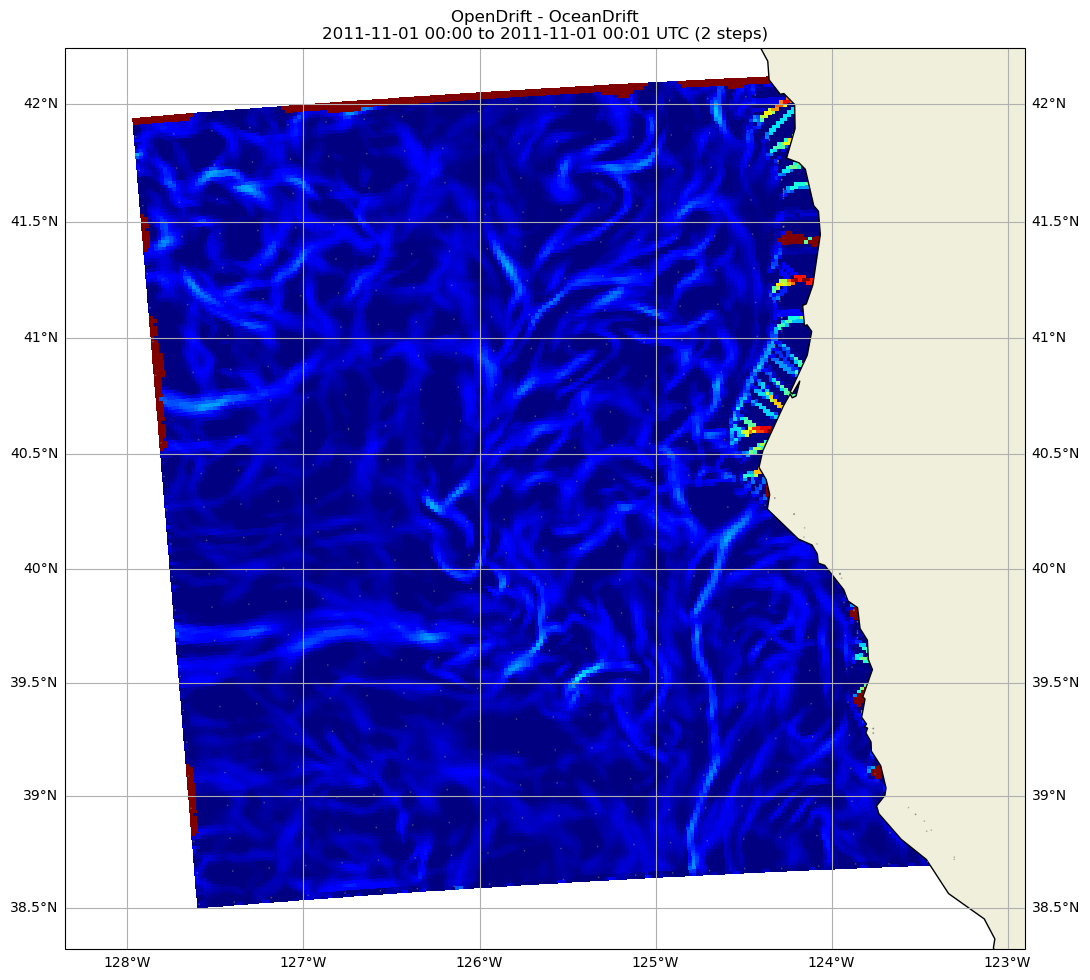

<Figure size 640x480 with 0 Axes>

In [231]:
o.plot(lcs=lcs, vmin=1e-7, vmax=1e-4, show_elements=False)
plt.savefig('./FTLE.png')

In [232]:
lcs

{'time': [datetime.datetime(2011, 11, 1, 0, 0)],
 'lon': array([[-127.5937393 , -127.57309396, -127.5524479 , ..., -123.20386558,
         -123.18311116, -123.16235643],
        [-127.59523136, -127.574582  , -127.55393192, ..., -123.20449732,
         -123.18373881, -123.16297999],
        [-127.59672401, -127.57607063, -127.55541652, ..., -123.2051293 ,
         -123.1843667 , -123.1636038 ],
        ...,
        [-127.9579557 , -127.93632922, -127.91470191, ..., -123.35811312,
         -123.3363611 , -123.31460874],
        [-127.95959399, -127.9379631 , -127.91633139, ..., -123.35880713,
         -123.33705063, -123.31529377],
        [-127.96123296, -127.93959766, -127.91796153, ..., -123.35950142,
         -123.33774043, -123.31597909]]),
 'lat': array([[38.50840792, 38.50970463, 38.51099781, ..., 38.70427653,
         38.7048231 , 38.70536612],
        [38.52297066, 38.52426763, 38.52556107, ..., 38.71887844,
         38.71942512, 38.71996825],
        [38.53753344, 38.53883066,

In [233]:
np.shape(alcs_data)


(1, 236, 215)

In [234]:
np.shape(np.array(Land_mask))
alcs_mapped = np.where(np.array((Land_mask[:-1,:-1]-1)*-1),lcs['ALCS'][0],np.nan)
alcs_mapped = np.reshape(alcs_mapped,(1,np.shape(alcs_mapped)[0],np.shape(alcs_mapped)[1]))
np.shape(alcs_mapped)
#np.shape([np.array(Land_mask[:-1,:-1])])
# np.array(Land_mask)[:213,:215].sum()
#np.shape(alcs_mapped)lat[:-1]

(1, 236, 215)

In [235]:
(Land_mask[:-1,:-1]-1)*-1
#np.shape(lat[:-1])

<xarray.DataArray 'land_binary_mask' (Y: 236, X: 215)>
array([[0, 0, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]])
Coordinates:
  * Y        (Y) int64 81172 82796 84420 86044 ... 457940 459564 461188 462812
  * X        (X) int64 -660722 -658918 -657114 ... -278274 -276470 -274666

###### alcs_mapped
ALCS = xr.DataArray(alcs_mapped, coords = [time,lat,lon], dims= ['time','lat','lon'],name='ALCS')

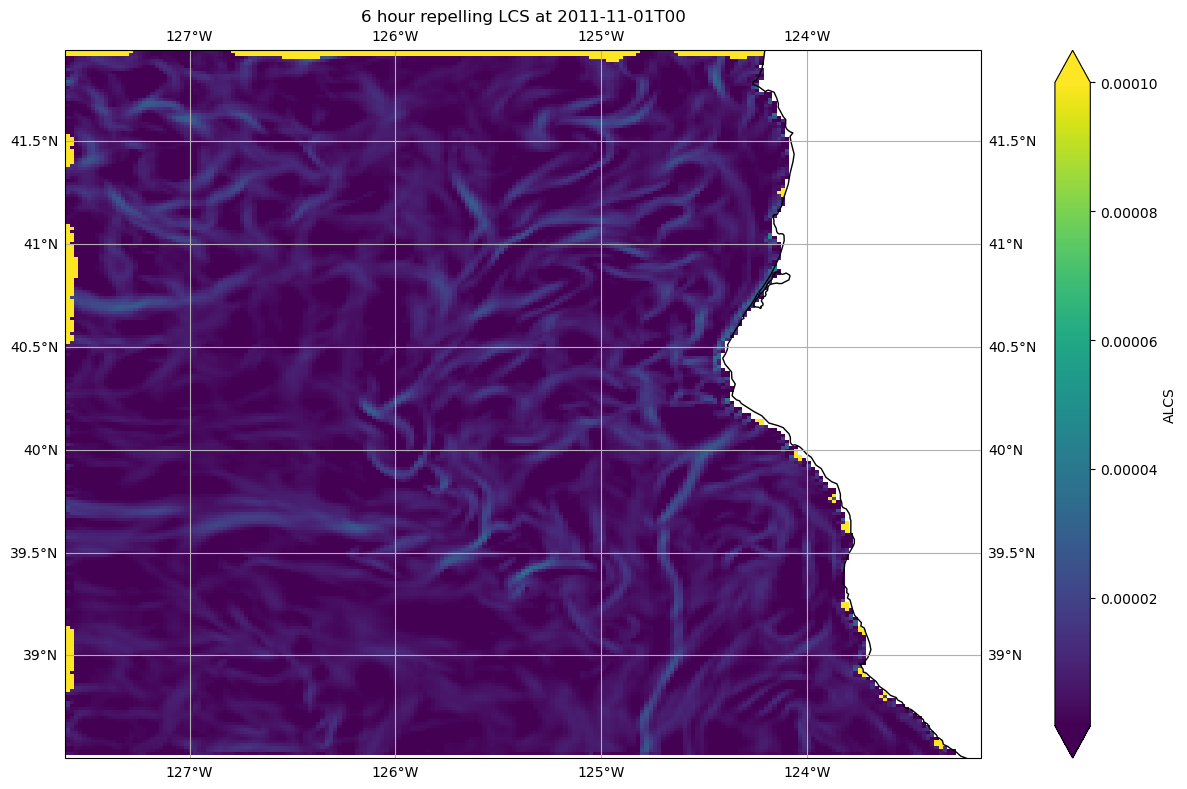

In [237]:
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=proj)
ALCS.plot(vmin=1e-7, vmax=1e-4,transform=ccrs.PlateCarree())
#test_uv_proj['u'].isel(time=0).plot()
#coast_10m = cfeature.NaturalEarthFeature("physical", "land", "10m", edgecolor="k", facecolor='.7')
plt.title("6 hour repelling LCS at " + str(np.array(ALCS.time)[0])[0:13]) 
#ax.add_feature(coast_10m)
gl = ax.gridlines(draw_labels=True)
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
ax.set_aspect('equal') 
ax.coastlines()
plt.savefig('./lcs_proj.png')

In [ ]:
# mean_diff = test_uv['X'].diff(dim='X').mean()#.isel(time=0).plot()
# print(mean_diff)
# print(test_uv['X'])#.diff(dim='X').mean()#.isel(time=0).plot()
# print(test_uv['Y'])
# time_cut = uv_cut['time']
# X_uniform = np.arange(-660722,-271237,1804)
# Y_uniform = np.arange(81172,465913,1624)
# print(len(X_uniform))
# print(len(Y_uniform))
# spatial_u = xr.DataArray(np.array(uv_cut['u']),coords = [time_cut,Y_uniform,X_uniform], dims = ['time','Y','X'],name='u')
# spatial_v = xr.DataArray(np.array(uv_cut['v']),coords = [time_cut,Y_uniform,X_uniform], dims = ['time','Y','X'],name='v')


In [ ]:
X_uniform_grid, Y_uniform_grid = np.meshgrid(X_uniform,Y_uniform)

In [ ]:
#plt.plot(test_uv['X'],test_uv['Y'])
#plt.plt
test_uv

In [ ]:
# spatial_u.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/u_spatial_short_uniform_try.nc')
# spatial_v.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/v_spatial_short_uniform_try.nc')



In [ ]:
# test_uv_filepaths = ['/media/basil/Elements/data/Thesis/LLC4320/test-working/v_spatial_short_uniform_try.nc','/media/basil/Elements/data/Thesis/LLC4320/test-working/u_spatial_short_uniform_try.nc'] 
# test_uv = xr.open_mfdataset(test_uv_filepaths)
# test_uv = xr.open_mfdataset(test_uv_filepaths)
# test_uv['u'].attrs['long_name'] = 'x_sea_water_velocity'
# test_uv['u'].attrs['units'] = 'm s-1'
# test_uv['u'].attrs['standard_name'] = 'x_sea_water_ve CCWG in locity'
# test_uv['u'].attrs['grid_mapping'] = 'epsg:3310'
# test_uv['v'].attrs['long_name'] = 'y_sea_water_velocity'
# test_uv['v'].attrs['units'] = 'm s-1'
# test_uv['v'].attrs['standard_name'] = 'y_sea_water_velocity'
# test_uv['v'].attrs['grid_mapping'] = 'epsg:3310'
# test_uv['Y'].attrs['long_name'] = 'projection_y_coordinate'
# test_uv['Y'].attrs['units'] = 'm'
# test_uv['Y'].attrs['standard_name'] = 'projection_y_coordinate'


# test_uv['X'].attrs['long_name'] = 'projection_x_coordinate'
# test_uv['X'].attrs['units'] = 'm'
# test_uv['X'].attrs['standard_name'] = 'projection_x_coordinate'
# proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs' #projection for epsg:3310
# #proj4 = '+proj=aea +lat_1=27.5 +lat_2=35 +lat_0=18 +lon_0=-100 +x_0=1500000 +y_0=6000000 +ellps=GRS80 +towgs84=0,0,0,0,0,0,0 +units=m +no_defs' #Lambert Conformal

In [ ]:
# test_uv
# projection = xr.Dataset(data_vars = dict(projection=1),attrs=dict(earth_radius=6371000.0,proj4 = '+proj=aea +lat_1=34 +lat_2=40.5 +lat_0=0 +lon_0=-120 +x_0=0 +y_0=-4000000 +datum=NAD83 +units=m +no_defs',)) 
# #test_uv_proj = xr.merge(test_uv,projection['projection'])
# projection['projection'].attrs = projection.attrs
# test_uv_proj = xr.merge([test_uv,projection])

In [ ]:
# test_uv_proj.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/test-working/final_proj_try.nc')

In [ ]:

# o = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
# o_diffusion = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
# o.set_config('general:coastline_action', 'stranding') 
# o.set_config('drift:advection_scheme', 'runge-kutta4')
# o.set_config('general:time_step_minutes', 60)
# o.set_config('drift:stokes_drift', False)
# o_diffusion.set_config('general:coastline_action', 'stranding') 
# o_diffusion.set_config('drift:advection_scheme', 'runge-kutta4')
# o_diffusion.set_config('general:time_step_minutes', 60)
# o_diffusion.set_config('drift:stokes_drift', False)
# o_diffusion.set_config('drift:current_uncertainty_uniform', .5)
# reader_data = reader_netCDF_CF_generic.Reader(test_uv_proj)
# reader_landmask = reader_global_landmask.Reader()
# o.add_reader([reader_data,reader_landmask])
# o_diffusion.add_reader([reader_data,reader_landmask])

In [ ]:
reader_data

In [ ]:
lcs = o.calculate_ftle(
    time=reader_data.start_time + timedelta(hours=0),
    time_step=timedelta(minutes=60),
    duration=timedelta(hours=6), delta=1000,
    RLCS=False)


In [ ]:
#uv_model['lat'][][]
#o.plot(lcs=lcs, vmin=1e-7, vmax=1e-4, colorbar=True,show_elements=False)

In [ ]:
for i in range(0,20):
    lcs = o.calculate_ftle(
        time=reader_data.start_time + timedelta(hours=6*i),
        time_step=timedelta(minutes=60),
        duration=timedelta(hours=6), delta=1000,
        RLCS=False)
    lcs_lat = lcs['lat']
    lcs_lon = lcs['lon']
    lcs_time = lcs['time']
    lcs_data = lcs['ALCS'].data
    time = lcs_time
    lat = lcs_lat[:,0]
    lon = lcs_lon[0,:]
    LCS = xr.DataArray(lcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='LCS')
    LCS.to_netcdf('/media/basil/Elements/data/Thesis/LLC4320/LCS_data_nc_test/lcs_test_data_'+str(i)+'.nc')

In [ ]:
LCS = LCS.where(LCS>0).where(LCS<1e-4)

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=proj)
LCS.plot(vmin=1e-7, vmax=1e-4,transform=ccrs.PlateCarree())

# coast_10m = cfeature.NaturalEarthFeature("physical", "land", "10m", edgecolor="k", facecolor="0.8")
# plt.title("6 hour attracting LCS at " + str(np.array(LCS.time)[0])[0:13]) 
# ax.add_feature(coast_10m)
# gl = ax.gridlines(draw_labels=True)
# gl.xformatter = LONGITUDE_FORMATTER
# gl.yformatter = LATITUDE_FORMATTER


In [ ]:
time = lcs_time
lat = lcs_lat[:,0]
lon = lcs_lon[0,:]
len(lat)

In [ ]:
LCS = xr.DataArray(lcs_data, coords = [time,lat,lon],dims = ['time','lat','lon'],name='LCS')

In [ ]:
LCS.plot(vmin=1e-7, vmax=1e-4,transform=ccrs.PlateCarree())


In [ ]:
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=proj)
LCS.plot(vmin=1e-7, vmax=1e-4,transform=ccrs.PlateCarree())

coast_10m = cfeature.NaturalEarthFeature("physical", "land", "10m", edgecolor="k", facecolor="0.8")
plt.title("6 hour attracting LCS at" + str(np.array(LCS.time)[0]) ) 
ax.add_feature(coast_10m)
gl = ax.gridlines(draw_labels=True)
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

In [ ]:
start_time = reader_data.start_time
#o.seed_cone(lon=uv_cut.lon, lat=uv_cut.lat, number=100, time=time)
#o.seed_elements(lon=-124.5249, lat=39.2598, number=5000, radius=1000, time=start_time)
#o.seed_elements(lon=lon_line[], lat=lat_line, number=len(lat_line), radius=1000, time=start_time)

In [ ]:
#o.run(duration=timedelta(hours=6), time_step=timedelta(minutes=30))

In [ ]:
#o.plot(fast=True)
lcs_files, lcs_filepaths = tools.get_data_paths_from_binary('/media/basil/Elements/data/Thesis/LLC4320/','LCS_data_nc_test',file_end='nc')
lcs = xr.open_mfdataset(lcs_filepaths)

In [ ]:
for i in range(0,20):
    proj = ccrs.PlateCarree()
    fig = plt.figure(figsize=(15, 8))
    ax = plt.axes(projection=proj)
    lcs['LCS'].isel(time=i).plot(vmin=1e-7, vmax=1e-4)
    coast_10m = cfeature.NaturalEarthFeature("physical", "land", "10m", edgecolor="k", facecolor="0.8")
    plt.title("6 hour attracting LCS at" + str(np.array(lcs.time)[i]) ) 
    ax.add_feature(coast_10m)
    gl = ax.gridlines(draw_labels=True)
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    plt.savefig('/media/basil/Elements/data/Thesis/LLC4320/animations/panels/lcs_test/test_anim_'+str(i)+'_.png')

In [ ]:
# from datetime import timedelta
# lcs = o.calculate_ftle(
#     time=reader_data.start_time + timedelta(hours=1),
#     time_step=timedelta(minutes=60),
#     duration=timedelta(hours=6), delta=1000,
#     RLCS=False)

In [ ]:
o.plot(lcs=lcs, vmin=1e-7, vmax=1e-4, colorbar=True,show_elements=False)

In [ ]:
lcs

In [ ]:
o = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o_diffusion = OceanDrift(loglevel=50) # Setting the log level will give the user different amounts of info (0=Debug (all), 20=Minimum, 50=None)
o.set_config('general:coastline_action', 'stranding') 
o.set_config('drift:advection_scheme', 'runge-kutta4')
o.set_config('general:time_step_minutes', 60)
o.set_config('drift:stokes_drift', False)
o_diffusion.set_config('general:coastline_action', 'stranding') 
o_diffusion.set_config('drift:advection_scheme', 'runge-kutta4')
o_diffusion.set_config('general:time_step_minutes', 60)
o_diffusion.set_config('drift:stokes_drift', False)
o_diffusion.set_config('drift:current_uncertainty_uniform', .5)

In [ ]:

reader_norkyst = reader_netCDF_CF_generic.Reader('/home/basil/Desktop/opendrift/tests/test_data/16Nov2015_NorKyst_z_surface/norkyst800_subset_16Nov2015.nc')
o.add_reader([reader_norkyst])
# lcs = o.calculate_ftle(
#     time=reader_norkyst.start_time + timedelta(hours=20),
#     time_step=timedelta(minutes=30),
#     duration=timedelta(hours=5), delta=1000,
#     RLCS=False)

In [ ]:
reader_norkyst

In [ ]:
# o = o.clone()
# o.seed_elements(lon=4.4, lat=60.2, number=1000, radius=1000,
#                 time=reader_norkyst.start_time)
# o.run(end_time=reader_norkyst.start_time+timedelta(hours=20),
#       time_step=timedelta(minutes=30))
o.plot(lcs=lcs, vmin=1e-7, vmax=1e-4, colorbar=True)

In [ ]:
data = xr.open_dataset('/home/basil/Desktop/opendrift/tests/test_data/16Nov2015_NorKyst_z_surface/norkyst800_subset_16Nov2015.nc')

###### data

In [ ]:
np.asarray(data['projection_stere'])

#test_uv['projection_stere'].attrs = data['projection_stere'].attrs

In [ ]:
plt.plot(data['X'])
#plt.plot(data['Y'])


In [ ]:
import opendrift.models as od_models
od_models.physics_methods.distance_along_trajectory([lon_line[6],lon_line[7]],[lat_line[0],lat_line[0]])
#in order to get FTLE, need to translate into position space X and Y

In [ ]:
lon_line[1]-lon_line[0]